In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/kaggle/input/uber-ride-analytics-dashboard/ncr_ride_bookings.csv")

In [2]:
df.info() # mostra tipos de dados.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [3]:
df['Avg VTAT'].isnull().sum()

10500

## Tratamento

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df['Avg VTAT'].mean()

8.456351971326166

In [6]:
df['Avg VTAT'].fillna(df['Avg VTAT'].mean(), inplace=True)

In [7]:
df['Avg VTAT'].isnull().sum()

0

In [8]:
df['Avg CTAT'].isnull().sum()

48000

## Analise exploratória

In [9]:
# 1. Visão das Primeiras Linhas
print("## 1. Visão Geral do Dataset (df.head())")
# Mostra o cabeçalho e permite identificar rapidamente os tipos de dados e valores
print(df.head())
print("-" * 50)

## 1. Visão Geral do Dataset (df.head())
         Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location   Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil   8.456352       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56   4.900000      14.0   
2           Auto              Khandsa      Malviya Nagar  13.400000      25.8   
3  Premier Sedan  Central Secretariat           Inderlok  13.100000      28.5   
4           Bike     Ghitorni Village        Khan Market   5.300000      19.6   

   ...  Reason for cancelling by Custom

In [10]:
# 2. Informações e Tipos de Dados
print("## 2. Tipos de Dados e Contagem de Não-Nulos (df.info())")
# Fundamental para ver se 'Date' e 'Time' estão como 'object' (string) ou 'datetime'
# E para ver a contagem total de 150.000 linhas.
df.info()
print("-" * 50)

## 2. Tipos de Dados e Contagem de Não-Nulos (df.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           150000 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-nu

In [11]:
# 3. Análise de Valores Ausentes (NaNs)
print("## 3. Análise de Missing Data (NaNs)")
# Calcula o percentual de NaNs por coluna, identificando as colunas problemáticas
nan_percent = df.isnull().sum() / len(df) * 100
nan_table = pd.DataFrame({'Total NaNs': df.isnull().sum(), 'Percentual (%)': nan_percent.round(2)})
nan_table = nan_table[nan_table['Total NaNs'] > 0].sort_values(by='Total NaNs', ascending=False)
print(nan_table)

# Avg CTAT', 'Booking Value' e 'Ride Distance' têm cerca de 32% de NaNs, 
# o que exigirá uma imputação cuidadosa na fase de Pré-processamento.

## 3. Análise de Missing Data (NaNs)
                                   Total NaNs  Percentual (%)
Incomplete Rides                       141000            94.0
Incomplete Rides Reason                141000            94.0
Cancelled Rides by Customer            139500            93.0
Reason for cancelling by Customer      139500            93.0
Cancelled Rides by Driver              123000            82.0
Driver Cancellation Reason             123000            82.0
Driver Ratings                          57000            38.0
Customer Rating                         57000            38.0
Avg CTAT                                48000            32.0
Booking Value                           48000            32.0
Ride Distance                           48000            32.0
Payment Method                          48000            32.0


In [12]:
# Colunas Categóricas Chave
CATEGORICAL_COLS = ['Booking Status', 'Vehicle Type', 'Payment Method', 'Pickup Location']

print("\n## 4. Análise de Variáveis Categóricas")

for col in CATEGORICAL_COLS:
    print(f"\n--- Coluna: {col} ---")
    # Usa value_counts para ver a frequência das categorias
    counts = df[col].value_counts(dropna=False).head(5) # Inclui NaNs na contagem se houver
    
    # Se houver muitas categorias (alta cardinalidade), mostre apenas as Top 5
    if df[col].nunique() > 50:
        print(f"Esta coluna tem {df[col].nunique()} valores únicos. Mostrando Top 5:")
    
    print(counts)

# - Booking Status: Mostra as classes de cancelamento (Crucial para o Target).
# - Pickup Location: Alta Cardinalidade (muitas categorias únicas). Isso será um desafio no One-Hot Encoding!


## 4. Análise de Variáveis Categóricas

--- Coluna: Booking Status ---
Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

--- Coluna: Vehicle Type ---
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
Name: count, dtype: int64

--- Coluna: Payment Method ---
Payment Method
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Name: count, dtype: int64

--- Coluna: Pickup Location ---
Esta coluna tem 176 valores únicos. Mostrando Top 5:
Pickup Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64


In [13]:
NUMERIC_FEATURES = [
    'Avg VTAT', 
    'Avg CTAT', 
    'Booking Value', 
    'Ride Distance', 
    'Driver Ratings', 
    'Customer Rating'
]

# 1. Preparação dos Dados para Correlação
# Para calcular a correlação, precisamos garantir que não há NaNs nas colunas.
# Usamos a imputação por Mediana nas colunas que têm dados ausentes.
df_corr = df[NUMERIC_FEATURES].copy()

# Imputação das colunas com NaNs
for col in ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']:
    # Checa se a coluna tem NaNs antes de imputar
    if df_corr[col].isnull().any():
        df_corr[col].fillna(df_corr[col].median(), inplace=True)


# 2. Cálculo da Matriz de Correlação (Coeficiente de Pearson)
correlation_matrix = df_corr[NUMERIC_FEATURES].corr()

print("✅ Matriz de Correlação (Valores)")
print(correlation_matrix.round(4))

✅ Matriz de Correlação (Valores)
                 Avg VTAT  Avg CTAT  Booking Value  Ride Distance  \
Avg VTAT           1.0000    0.0508        -0.0069         0.0505   
Avg CTAT           0.0508    1.0000         0.0032         0.1022   
Booking Value     -0.0069    0.0032         1.0000         0.0101   
Ride Distance      0.0505    0.1022         0.0101         1.0000   
Driver Ratings    -0.0063   -0.0161        -0.0115        -0.0195   
Customer Rating   -0.0058   -0.0222        -0.0158        -0.0202   

                 Driver Ratings  Customer Rating  
Avg VTAT                -0.0063          -0.0058  
Avg CTAT                -0.0161          -0.0222  
Booking Value           -0.0115          -0.0158  
Ride Distance           -0.0195          -0.0202  
Driver Ratings           1.0000           0.0119  
Customer Rating          0.0119           1.0000  


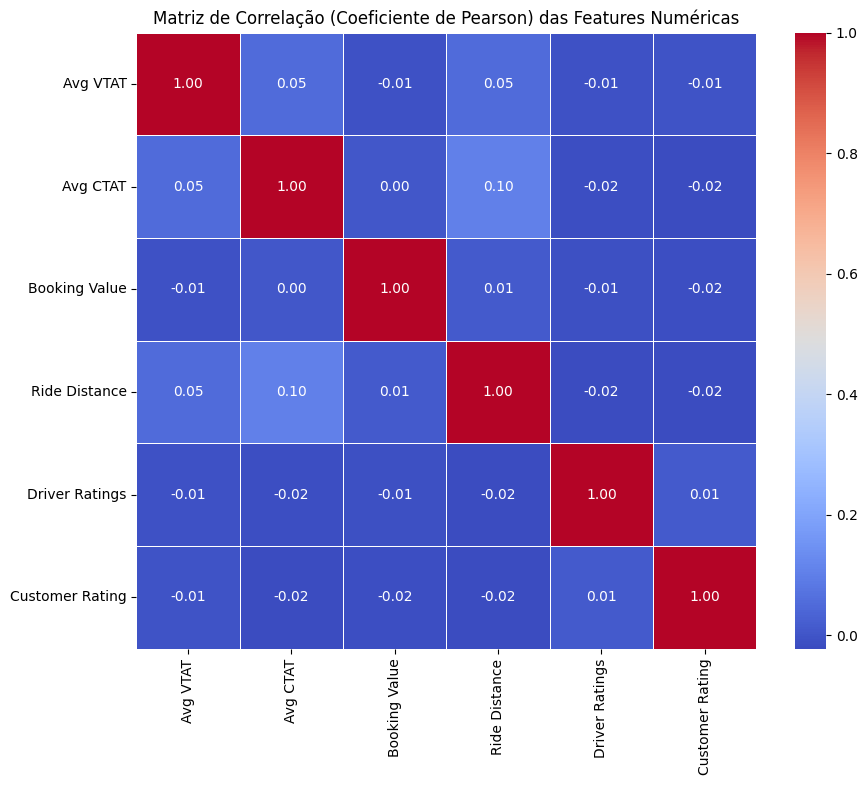

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 4. Visualização com Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,     # Mostrar os valores de correlação
            fmt=".2f",      # Formatar com 2 casas decimais
            cmap='coolwarm', # Cores quentes para correlação positiva, frias para negativa
            linewidths=.5,  # Linhas de separação
            cbar=True)
plt.title('Matriz de Correlação (Coeficiente de Pearson) das Features Numéricas')
plt.show()

## Detecção de anomalias e padrões

In [15]:
## Conversão e normalização de tempo e data
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

# 3. Engenharia de Features de Tempo para Análise de Padrões
df['Dia_da_Semana'] = df['DateTime'].dt.day_name()
df['Hora_do_Dia'] = df['DateTime'].dt.hour
df['Dia_da_Semana_Num'] = df['DateTime'].dt.dayofweek # 0=Segunda, 6=Domingo

print("✅ Features de Tempo criadas com sucesso!")

✅ Features de Tempo criadas com sucesso!


In [16]:
## Padrão de Demanda por Hora do Dia
print("\n## Padrão de Demanda por Hora do Dia (Top 5)")

# Contar o número de reservas por 'Hora_do_Dia'
demanda_hora = df.groupby('Hora_do_Dia')['Booking ID'].count().sort_values(ascending=False)

print(demanda_hora.head())


## Padrão de Demanda por Hora do Dia (Top 5)
Hora_do_Dia
18    12397
19    11047
17    11044
16     9633
20     9630
Name: Booking ID, dtype: int64


In [17]:
## Padrão de Demanda por Dia da Semana
print("\n## Padrão de Demanda por Dia da Semana")

# Ordem correta dos dias da semana
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Contar o número de reservas por 'Dia_da_Semana' e reordenar
demanda_dia = df.groupby('Dia_da_Semana')['Booking ID'].count().reindex(dias_ordem)

print(demanda_dia)


## Padrão de Demanda por Dia da Semana
Dia_da_Semana
Monday       21644
Tuesday      21391
Wednesday    21413
Thursday     21215
Friday       21397
Saturday     21542
Sunday       21398
Name: Booking ID, dtype: int64


In [18]:
## Detecção de Anomalias (Outliers) usando IQR

# 1. Escolher a coluna e remover NaNs (necessário para cálculos estatísticos)
coluna_analise = 'Booking Value'
df_limpo = df.dropna(subset=[coluna_analise])

# 2. Calcular o Q1, Q3 e o IQR
# Q1: O 25º percentil. 25% dos valores são menores ou iguais a este número.
Q1 = df_limpo[coluna_analise].quantile(0.25)

# Q3: O 75º percentil. 75% dos valores são menores ou iguais a este número.
Q3 = df_limpo[coluna_analise].quantile(0.75)

# IQR (Intervalo Interquartil): É a amplitude dos 50% centrais dos dados (Q3 - Q1).
# Ele mede a dispersão dos dados "típicos".
IQR = Q3 - Q1

# 3. Definir os limites de anomalia (1.5 * IQR)
# O fator 1.5 é o padrão estatístico para identificar 'outliers leves'.
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\n## Análise de Anomalias para '{coluna_analise}'")
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Limite Superior (Anomalia): {limite_superior:.2f}")
print(f"Limite Inferior (Anomalia): {limite_inferior:.2f}")

# 4. Filtrar as anomalias: Procuramos valores que caem fora da faixa [Limite Inferior, Limite Superior]
anomalias = df_limpo[
    (df_limpo[coluna_analise] < limite_inferior) | 
    (df_limpo[coluna_analise] > limite_superior)
]

print("-" * 20)
print(anomalias['Booking Value'].head())
print(f"Total de anomalias {len(anomalias)}")


## Análise de Anomalias para 'Booking Value'
Q1 (25%): 234.00
Q3 (75%): 689.00
IQR: 455.00
Limite Superior (Anomalia): 1371.50
Limite Inferior (Anomalia): -448.50
--------------------
29     2847.0
50     1581.0
80     1390.0
91     2169.0
212    1543.0
Name: Booking Value, dtype: float64
Total de anomalias 3435


## Preparando dados para um modelo

### Definição de dados

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Definição do Target e Features
# Variável Target (Alvo): Prever se a corrida foi cancelada ou completada.
TARGET = 'Booking Status' 

# Colunas que usaremos como Features (Variáveis Preditivas)
FEATURES = [
    'Date', 'Time', 'Vehicle Type', 'Pickup Location', 'Drop Location', 
    'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 
    'Driver Ratings', 'Customer Rating', 'Payment Method'
]

# 2. Copiar o DataFrame e lidar com NaNs
# Criamos uma cópia para evitar warnings e fazemos uma imputação simples.
df_ml = df[FEATURES + [TARGET]].copy()

# Imputação Simples para colunas numéricas (usaremos a Mediana)
numeric_cols_impute = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
for col in numeric_cols_impute:
    df_ml[col].fillna(df_ml[col].median(), inplace=True)

print("✅ Limpeza inicial de NaNs por Mediana concluída.")

✅ Limpeza inicial de NaNs por Mediana concluída.


### Engenharia de Features

In [20]:
# 1. Conversão e Combinação de Tempo
df_ml['DateTime'] = pd.to_datetime(df_ml['Date'] + ' ' + df_ml['Time'])

# 2. Criação de Novas Features
df_ml['Dia_da_Semana'] = df_ml['DateTime'].dt.day_name()
df_ml['Hora_do_Dia'] = df_ml['DateTime'].dt.hour

# Adicionamos as novas features à lista
FEATURES.append('Dia_da_Semana')
FEATURES.append('Hora_do_Dia')
FEATURES.remove('Date') # Removemos as colunas originais de data/hora
FEATURES.remove('Time')

print("✅ Engenharia de Features de Tempo")

✅ Engenharia de Features de Tempo


In [21]:
print(FEATURES)

['Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method', 'Dia_da_Semana', 'Hora_do_Dia']


In [22]:
# Sucesso (Completed) = 0
# Falha/Cancelamento/Incomplete = 1
mapping_status_binario = {
    'Completed': 0,
    'Cancelled': 1,               # Inclui 'Cancelled' genérico, se houver
    'Cancelled by Customer': 1,
    'Cancelled by Driver': 1,
    'Incomplete': 1
}

# 3.1. Aplica o Mapeamento
# Qualquer status NÃO listado no dicionário acima será convertido para NaN.
df_ml[TARGET] = df_ml[TARGET].map(mapping_status_binario)

# 3.2. Limpeza Final do Target
# Remove as linhas que resultaram em NaN (ou seja, statuses que não foram mapeados)
# Esta é a linha que resolve o 'ValueError: Input y contains NaN'.
df_ml.dropna(subset=[TARGET], inplace=True)

# 3.3. Converte para o Tipo Inteiro (Obrigatório para Target Binário)
df_ml[TARGET] = df_ml[TARGET].astype(int)

print("✅ Engenharia de Features de Codificação do Target concluídas.")

✅ Engenharia de Features de Codificação do Target concluídas.


## Como selecionar os dados

> Nessa etapa é importante que os dados já estejam devidamente tratados

### Separação de dados de treino e teste

In [23]:
# 1. Definição do Target e Features
# Variável Target (Alvo): Prever se a corrida foi cancelada ou completada.
TARGET = 'Booking Status' 

# Colunas que usaremos como Features (Variáveis Preditivas)
FEATURES = [
    'Date', 'Time', 'Vehicle Type', 'Pickup Location', 'Drop Location', 
    'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 
    'Driver Ratings', 'Customer Rating', 'Payment Method'
]

In [24]:
from sklearn.model_selection import train_test_split

# 4. Divisão dos dados entre features e target
X = df_ml.drop(TARGET, axis=1)
y = df_ml[TARGET]

# Fazemos o split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       
    random_state=42,     
    stratify=y           
)
print("✅ Dados separados entre treino e teste")

✅ Dados separados entre treino e teste


### Categorização

In [25]:
# Colunas numéricas (para escalonamento)
numeric_features = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Hora_do_Dia']

# Colunas Categóricas (para One-Hot Encoding)
# Usaremos 'Pickup Location' e 'Drop Location' como exemplo, mas na prática com 150k linhas, 
# se tiverem muitas categorias únicas, usaríamos outra técnica (ex: Target Encoding).
categorical_features = ['Vehicle Type', 'Payment Method', 'Dia_da_Semana', 'Pickup Location', 'Drop Location']

In [51]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 8. Criação do Pré-processador (ColumnTransformer)

preprocessor = ColumnTransformer(
    transformers=[
        # 1. ESCALONAMENTO para Variáveis Numéricas
        ('num', 
         StandardScaler(), # Aplica a padronização (Média=0, Desvio Padrão=1)
         numeric_features),
        
        # 2. CODIFICAÇÃO para Variáveis Categóricas
        ('cat', 
         OneHotEncoder(handle_unknown='ignore', sparse_output=False), # Cria colunas binárias (0 ou 1)
         categorical_features)
    ],
    remainder='drop' # Ignora colunas que não estão nas listas acima (ex: 'DateTime')
)

# 9. Aplicar o Pré-processador nos dados de Treino e Teste
# .fit_transform() calcula as estatísticas (média, std) E aplica a transformação (SOMENTE no treino!)
X_train_processed = preprocessor.fit_transform(X_train)

# .transform() APENAS aplica as estatísticas aprendidas no treino (APLICAR no teste!)
X_test_processed = preprocessor.transform(X_test)


print("\n## Resultados das Transformações:")
print("✅ ColumnTransformer configurado e aplicado com sucesso.")
print("✅ Escalonamento (StandardScaler) aplicado a colunas numéricas.")
print("✅ Codificação (OneHotEncoder) aplicada a colunas categóricas.")
print(f"Shape de X_train_processed (Número de Features): {X_train_processed.shape}")


## Resultados das Transformações:
✅ ColumnTransformer configurado e aplicado com sucesso.
✅ Escalonamento (StandardScaler) aplicado a colunas numéricas.
✅ Codificação (OneHotEncoder) aplicada a colunas categóricas.
Shape de X_train_processed (Número de Features): (111600, 379)


In [52]:
# Obter os nomes das features APÓS a transformação
# Usamos o pré-processador JÁ treinado (fit)
feature_names = preprocessor.get_feature_names_out()

# Exemplo de como serão os nomes: 
# ['num__Avg VTAT', 'num__Avg CTAT', ..., 'cat__Vehicle Type_Compact', 'cat__Payment Method_Cash', ...]
print(f"Total de Novas Colunas (Features): {len(feature_names)}")

Total de Novas Colunas (Features): 379


In [28]:
print(feature_names)

['num__Avg VTAT' 'num__Avg CTAT' 'num__Booking Value' 'num__Ride Distance'
 'num__Driver Ratings' 'num__Customer Rating' 'num__Hora_do_Dia'
 'cat__Vehicle Type_Auto' 'cat__Vehicle Type_Bike'
 'cat__Vehicle Type_Go Mini' 'cat__Vehicle Type_Go Sedan'
 'cat__Vehicle Type_Premier Sedan' 'cat__Vehicle Type_Uber XL'
 'cat__Vehicle Type_eBike' 'cat__Payment Method_Cash'
 'cat__Payment Method_Credit Card' 'cat__Payment Method_Debit Card'
 'cat__Payment Method_UPI' 'cat__Payment Method_Uber Wallet'
 'cat__Payment Method_nan' 'cat__Dia_da_Semana_Friday'
 'cat__Dia_da_Semana_Monday' 'cat__Dia_da_Semana_Saturday'
 'cat__Dia_da_Semana_Sunday' 'cat__Dia_da_Semana_Thursday'
 'cat__Dia_da_Semana_Tuesday' 'cat__Dia_da_Semana_Wednesday'
 'cat__Pickup Location_AIIMS' 'cat__Pickup Location_Adarsh Nagar'
 'cat__Pickup Location_Akshardham' 'cat__Pickup Location_Ambience Mall'
 'cat__Pickup Location_Anand Vihar'
 'cat__Pickup Location_Anand Vihar ISBT' 'cat__Pickup Location_Ardee City'
 'cat__Pickup Location

In [29]:
# 9.2. Transformar o Array NumPy de Volta para DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)

# O índice original do Pandas é perdido no processo, então o Pandas atribui um novo índice sequencial. 
# Se você quiser manter o índice original do X_train para comparação:
X_train_df.index = X_train.index

print("\n✅ DataFrame Reconstituído (X_train Processado):")
print(X_train_df.head())
print(f"\nColunas do Novo DataFrame: {X_train_df.columns.tolist()[:10]}...") # Mostra as primeiras 10 colunas


✅ DataFrame Reconstituído (X_train Processado):
        num__Avg VTAT  num__Avg CTAT  num__Booking Value  num__Ride Distance  \
103181      -0.095391       0.242080            1.233564           -1.521633   
69601       -1.631434       0.189506           -1.110040           -1.185887   
94291        2.314606      -0.033933           -0.201893           -0.055875   
4173        -0.810445       0.728389           -0.363016           -0.193681   
141780       1.414168      -0.125937            0.161365            0.813557   

        num__Driver Ratings  num__Customer Rating  num__Hora_do_Dia  \
103181             1.246462             -0.379073         -0.007541   
69601              0.128082              0.731523         -0.376494   
94291              0.128082              0.176225          0.545888   
4173               1.246462             -0.379073          0.545888   
141780            -2.667866              1.564469         -0.560971   

        cat__Vehicle Type_Auto  cat__Vehicl

In [30]:
# Exemplo de Comparação (Visual para o Curso)

indice_exemplo = X_train.index[0]

print("\n--- 🔎 Comparação de Dados (Índice:", indice_exemplo, ") ---")

# Dados Originais (X_train)
print("\n[ORIGINAL - Antes do Processamento]")
print(X_train.loc[indice_exemplo, ['Ride Distance', 'Booking Value', 'Vehicle Type', 'Avg VTAT']])

# Dados Transformados (X_train_df)
print("\n[PROCESSADO - Depois do StandardScaler e OneHotEncoder]")

# Foco nas colunas escalonadas (note que estão centralizadas perto de 0)
colunas_escalonadas = ['num__Ride Distance', 'num__Booking Value', 'num__Avg VTAT']
print(X_train_df.loc[indice_exemplo, colunas_escalonadas])

# Foco nas colunas codificadas (o valor 1 indica a categoria dessa linha)
colunas_categoricas = [col for col in X_train_df.columns if 'cat__Vehicle Type' in col]
print(X_train_df.loc[indice_exemplo, colunas_categoricas].head(5))


--- 🔎 Comparação de Dados (Índice: 103181 ) ---

[ORIGINAL - Antes do Processamento]
Ride Distance     6.17
Booking Value    904.0
Vehicle Type      Auto
Avg VTAT           8.1
Name: 103181, dtype: object

[PROCESSADO - Depois do StandardScaler e OneHotEncoder]
num__Ride Distance   -1.521633
num__Booking Value    1.233564
num__Avg VTAT        -0.095391
Name: 103181, dtype: float64
cat__Vehicle Type_Auto             1.0
cat__Vehicle Type_Bike             0.0
cat__Vehicle Type_Go Mini          0.0
cat__Vehicle Type_Go Sedan         0.0
cat__Vehicle Type_Premier Sedan    0.0
Name: 103181, dtype: float64


## Treinando modelo Supervisionado

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Dicionário para armazenar métricas e facilitar a comparação
metricas_comparacao = {}

# -----------------------------------------------------
# Modelo 1: Regressão Logística (Baseline)
# -----------------------------------------------------
print("## 1. Treinando Regressão Logística...")
# max_iter=1000 para garantir a convergência
model_lr = LogisticRegression(random_state=42, 
                              solver='liblinear', 
                              max_iter=1000)

model_lr.fit(X_train_processed, y_train)

# Predições
y_pred_lr = model_lr.predict(X_test_processed)
y_proba_lr = model_lr.predict_proba(X_test_processed)[:, 1] # Probabilidade da classe 1 (Cancelado)

# from sklearn.metrics import accuracy_score, roc_auc_score
# Armazenar métricas
metricas_comparacao['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'AUC': roc_auc_score(y_test, y_proba_lr)
}

print("✅ Treinamento de Regressão Logística concluído!")

## 1. Treinando Regressão Logística...
✅ Treinamento de Regressão Logística concluído!


In [54]:

# -----------------------------------------------------
# Modelo 2: Random Forest (Modelo mais Complexo)
# -----------------------------------------------------
print("\n## 2. Treinando Random Forest...")
# Usamos poucos estimadores (n_estimators) para agilizar a demo
model_rf = RandomForestClassifier(n_estimators=100, 
                                  max_depth=10, 
                                  random_state=42, 
                                  n_jobs=-1)
model_rf.fit(X_train_processed, y_train)

# Predições
y_pred_rf = model_rf.predict(X_test_processed)
y_proba_rf = model_rf.predict_proba(X_test_processed)[:, 1]

# Armazenar métricas
metricas_comparacao['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'AUC': roc_auc_score(y_test, y_proba_rf)
}

print("✅ Treinamento de Random Forest concluído!")


## 2. Treinando Random Forest...
✅ Treinamento de Random Forest concluído!


In [34]:
# -----------------------------------------------------
# A) Análise Detalhada (para o vídeo)
# -----------------------------------------------------
print("\n--- 📊 3. Relatório Detalhado: Regressão Logística ---")
print(classification_report(y_test, y_pred_lr, target_names=['Completed (0)', 'Cancelled (1)']))

print("\nMatriz de Confusão (Logistic Regression):")
# 
print(confusion_matrix(y_test, y_pred_lr))

print("\n--- 📊 4. Relatório Detalhado: Random Forest ---")
print(classification_report(y_test, y_pred_rf, target_names=['Completed (0)', 'Cancelled (1)']))

print("\nMatriz de Confusão (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))


--- 📊 3. Relatório Detalhado: Regressão Logística ---
               precision    recall  f1-score   support

Completed (0)       0.94      0.97      0.96     18600
Cancelled (1)       0.95      0.87      0.91      9300

     accuracy                           0.94     27900
    macro avg       0.94      0.92      0.93     27900
 weighted avg       0.94      0.94      0.94     27900


Matriz de Confusão (Logistic Regression):
[[18134   466]
 [ 1173  8127]]

--- 📊 4. Relatório Detalhado: Random Forest ---
               precision    recall  f1-score   support

Completed (0)       0.92      1.00      0.96     18600
Cancelled (1)       1.00      0.82      0.90      9300

     accuracy                           0.94     27900
    macro avg       0.96      0.91      0.93     27900
 weighted avg       0.95      0.94      0.94     27900


Matriz de Confusão (Random Forest):
[[18600     0]
 [ 1657  7643]]


In [35]:
# -----------------------------------------------------
# B) Comparação Final
# -----------------------------------------------------
print("\n--- 🏆 5. Comparação de Performance ---")
df_comparacao = pd.DataFrame(metricas_comparacao).T
print(df_comparacao)

# Comparação do AUC (AUC é ideal para problemas desbalanceados como este)
# -----------------------------------------------------
# AUC (Area Under the Curve)
# -----------------------------------------------------

# O AUC é a métrica padrão para avaliar a performance de modelos de Classificação Binária.
# Ele significa 'Área Sob a Curva ROC (Receiver Operating Characteristic)'.

# 1. O que mede? O AUC mede a capacidade do seu modelo de distinguir (discriminar) entre as classes
#    (neste caso, 'Completed' vs. 'Cancelled') em todos os limiares de classificação.

# 2. Interpretação: O valor do AUC é, essencialmente, a probabilidade de o modelo
#    classificar uma instância positiva real (um cancelamento) mais alta do que uma
#    instância negativa real (uma corrida completa).

# 3. Valores:
#    - AUC = 1.0: Modelo Perfeito.
#    - AUC = 0.5: Modelo não é melhor que o chute aleatório.

# 4. Vantagem: É crucial para datasets desbalanceados (como o nosso, onde o número
#    de corridas completas é muito maior que o de cancelamentos), pois não é influenciado
#    pela proporção de classes, dando uma medida mais verdadeira da qualidade do ranking de previsões.

print(f"\nMelhor Performance (AUC): {df_comparacao['AUC'].idxmax()}")
print(f"Melhor AUC: {df_comparacao['AUC'].max():.4f}")


--- 🏆 5. Comparação de Performance ---
                     Accuracy       AUC
Logistic Regression  0.941254  0.987482
Random Forest        0.940609  0.999577

Melhor Performance (AUC): Random Forest
Melhor AUC: 0.9996


## Treinando modelos não supervisionados

✅ Features Numéricas Isoladas: 7 colunas escalonadas.

## 1. Determinando 'K' Ideal (Método do Cotovelo)...


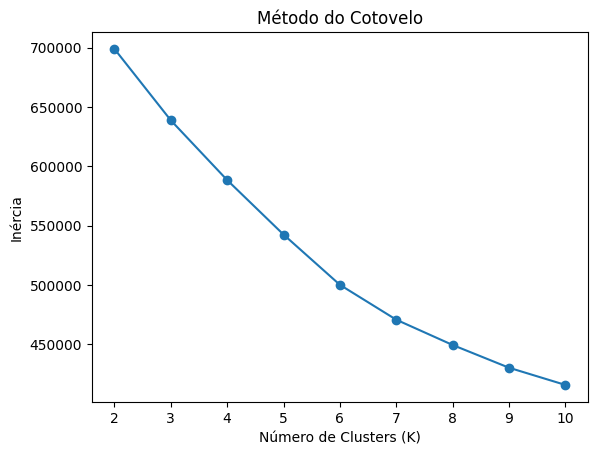

👉 Assumindo K ideal = 4 com base no 'cotovelo'.


In [55]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

feature_labels = [
    'Avg VTAT', 
    'Avg CTAT', 
    'Booking Value', 
    'Ride Distance', 
    'Driver Ratings', 
    'Customer Rating', 
    'Hora_do_Dia'
]

X_numeric = X_train_processed[:, :len(feature_labels)] 

print(f"✅ Features Numéricas Isoladas: {X_numeric.shape[1]} colunas escalonadas.")

# -----------------------------------------------------
# B. Método do Cotovelo para K-Means (Visualização para o Vídeo)
# -----------------------------------------------------
print("\n## 1. Determinando 'K' Ideal (Método do Cotovelo)...")
inertia_scores = []
K_range = range(2, 11) # Testar de 2 a 10 clusters

for k in K_range:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model.fit(X_numeric)
    inertia_scores.append(kmeans_model.inertia_)

plt.plot(K_range, inertia_scores, marker='o')
plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.show() 

K_ideal = 4
print(f"👉 Assumindo K ideal = {K_ideal} com base no 'cotovelo'.")

In [56]:
K_ideal = 6

In [57]:
# -----------------------------------------------------
# Modelo 1: K-Means Clustering
# -----------------------------------------------------
print("\n## 2. K-Means Clustering")
model_kmeans = KMeans(n_clusters=K_ideal, random_state=42, n_init=10)
clusters_kmeans = model_kmeans.fit_predict(X_numeric)

# Métrica Interna: Coeficiente de Silhueta
silhouette_k_means = silhouette_score(X_numeric, clusters_kmeans)
print(f"Silhueta Score (K-Means): {silhouette_k_means:.4f}")
print(f"Clusters encontrados (K-Means): {np.unique(clusters_kmeans)}")


## 2. K-Means Clustering
Silhueta Score (K-Means): 0.1354
Clusters encontrados (K-Means): [0 1 2 3 4 5]


In [39]:
# -----------------------------------------------------
# Modelo 2: DBSCAN (Density-Based)
# -----------------------------------------------------
print("\n## 3. DBSCAN Clustering (Baseado em Densidade)")
# Estes parâmetros são exemplos, você precisaria de um gráfico de k-distância para otimizar.
epsilon = 0.5 
min_samples = 10 

model_dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters_dbscan = model_dbscan.fit_predict(X_numeric)

# Os clusters no DBSCAN são de 0 a N, e -1 indica OUTLIERS (Ruído)
n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_outliers = np.sum(clusters_dbscan == -1)

print(f"Clusters encontrados (DBSCAN): {n_clusters_dbscan}")
print(f"Outliers (-1) encontrados: {n_outliers}")

# Se o DBSCAN encontrar clusters suficientes (>1), calcule a Silhueta
if n_clusters_dbscan > 1:
    # A Silhueta é calculada apenas para pontos que não são outliers (-1)
    mask = clusters_dbscan != -1
    silhouette_dbscan = silhouette_score(X_numeric[mask], clusters_dbscan[mask])
    print(f"Silhueta Score (DBSCAN, excluindo Outliers): {silhouette_dbscan:.4f}")
else:
    print("DBSCAN encontrou 0 ou 1 cluster. Silhueta não calculada.")


## 3. DBSCAN Clustering (Baseado em Densidade)
Clusters encontrados (DBSCAN): 5
Outliers (-1) encontrados: 75240
Silhueta Score (DBSCAN, excluindo Outliers): 0.0603


In [40]:
# -----------------------------------------------------
# 4. Análise e Interpretação dos Resultados (K-Means)
# -----------------------------------------------------
print("\n## 4. Análise dos Clusters (K-Means)")

# Adiciona os rótulos de cluster de volta ao DataFrame de Treino original (APENAS features numéricas)
# Nota: É mais fácil interpretar se você tiver os nomes originais das features.
# Para a demo, criaremos um DataFrame temporário com os rótulos:
X_numeric_df = pd.DataFrame(X_numeric, columns=feature_labels)
X_numeric_df['Cluster_KMeans'] = clusters_kmeans

# Calcular as médias de cada cluster
cluster_medians = X_numeric_df.groupby('Cluster_KMeans').median()
print(cluster_medians)


## 4. Análise dos Clusters (K-Means)
                Avg VTAT  Avg CTAT  Booking Value  Ride Distance  \
Cluster_KMeans                                                     
0              -0.333743 -0.033933      -0.201893      -0.055875   
1               1.016915 -0.033933      -0.201893      -0.055875   
2               0.063510  0.294654      -0.231188       0.328312   
3              -0.095391 -0.033933       2.522546       0.005094   
4              -0.704511 -0.033933      -0.201893      -0.055875   
5               0.010543  0.202649      -0.231188       0.170044   

                Driver Ratings  Customer Rating  Hora_do_Dia  
Cluster_KMeans                                                
0                     0.128082         0.176225    -1.114400  
1                     0.128082         0.176225     0.361412  
2                    -1.829081         0.176225     0.176935  
3                     0.128082         0.176225     0.176935  
4                     0.128082         

In [41]:
# =========================================================
# 5. Interpretação dos 6 Clusters K-Means (Valores ESCALADOS)
# =========================================================

print("\n--- 🎯 Interpretação dos 6 Clusters ---")
# Lembrete de Interpretação dos Valores Escalonados:
# - Valor Próximo de 0: Próximo da Média do Dataset (comportamento típico).
# - Valor Positivo (+): Acima da Média.
# - Valor Negativo (-): Abaixo da Média.

# As features são: Avg VTAT, Avg CTAT, Booking Value, Ride Distance, Driver Ratings, Customer Rating, Hora_do_Dia

# ----------------------------------------------------------------------------------------------------
# Cluster 0: "Viagens Fora de Pico (Típicas, Baixo VTAT)"
# ----------------------------------------------------------------------------------------------------
# - Avg VTAT: Significativamente ABAIXO da média (-0.33). Indica um tempo de atribuição de veículo mais rápido.
# - Hora_do_Dia: Abaixo da média (-1.11). Sugere horários muito fora de pico (madrugada ou início da manhã).
# - Outras Features: Todas próximas da média.
# INTERPRETAÇÃO: Corridas que se beneficiam da baixa demanda. O tempo de espera por um motorista é muito baixo.

# ----------------------------------------------------------------------------------------------------
# Cluster 1: "Viagens de Alta Espera por Veículo (Alto VTAT)"
# ----------------------------------------------------------------------------------------------------
# - Avg VTAT: Fortemente ACIMA da média (+1.01). Indica que o tempo de atribuição de veículo é muito elevado.
# - Outras Features: Todas próximas da média.
# INTERPRETAÇÃO: Corridas que enfrentam longos tempos de espera por um motorista. Pode ser uma área de baixa densidade de motoristas ou alta demanda inesperada.

# ----------------------------------------------------------------------------------------------------
# Cluster 2: "Corridas Longas com Motoristas Mal Avaliados"
# ----------------------------------------------------------------------------------------------------
# - Driver Ratings: Extremamente BAIXO (-1.82). Ponto de destaque.
# - Ride Distance: ACIMA da média (+0.32).
# - Avg CTAT: Acima da média (+0.29).
# INTERPRETAÇÃO: Corridas mais longas, associadas a um serviço de motorista de baixa qualidade. O fator limitante é a avaliação do motorista.

# ----------------------------------------------------------------------------------------------------
# Cluster 3: "Viagens Premium (Valor Extremamente Alto)"
# ----------------------------------------------------------------------------------------------------
# - Booking Value: Extremamente ACIMA da média (+2.52). Este é o maior desvio positivo de toda a tabela.
# - Ride Distance: Próximo da média (+0.005). Isso é crucial!
# - Outras Features: Todas próximas da média.
# INTERPRETAÇÃO: Viagens que possuem um valor de reserva muito alto **sem serem necessariamente longas**. Sugere o uso de veículos de luxo (Uber XL/Premier, se existirem) ou tarifas de surto (surge pricing) extremamente altas.

# ----------------------------------------------------------------------------------------------------
# Cluster 4: "Viagens de Pico da Tarde com Baixo VTAT"
# ----------------------------------------------------------------------------------------------------
# - Avg VTAT: Significativamente ABAIXO da média (-0.70). Tempo de atribuição de veículo muito rápido.
# - Hora_do_Dia: ACIMA da média (+0.73). Indica viagens concentradas no horário de pico da tarde/noite.
# INTERPRETAÇÃO: Um grupo de corridas de pico onde a alocação de motoristas está excepcionalmente eficiente.

# ----------------------------------------------------------------------------------------------------
# Cluster 5: "Viagens Longas com Clientes Mal Avaliados"
# ----------------------------------------------------------------------------------------------------
# - Customer Rating: Extremamente BAIXO (-2.04). O ponto de destaque, clientes com histórico de piores avaliações.
# - Ride Distance: Acima da média (+0.17).
# - Avg CTAT: Acima da média (+0.20).
# INTERPRETAÇÃO: Clientes com baixíssima avaliação que realizam corridas um pouco mais longas e com tempo de confirmação/localização ligeiramente maior. O fator limitante é o cliente.


--- 🎯 Interpretação dos 6 Clusters ---


### Métricas

In [42]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
import numpy as np

print("--- 🥇 Métricas para Classificação (Previsão de Cancelamento) ---")

# Usando o modelo Random Forest (model_rf) como exemplo para as métricas:
print("\n[Métricas do Random Forest]")

# 1. ACURÁCIA (ACCURACY)
# O que é: A métrica mais simples. É a porcentagem de todas as previsões (acertos e erros) que estavam corretas.
# Exemplo: Se o modelo previu 100 corridas e acertou 90, a Acurácia é de 90%.
# IMPORTÂNCIA: É a sua linha de base. Mas cuidado: em dados com pouquíssimos cancelamentos (desbalanceados), 
# um modelo ruim pode ter Acurácia alta (ex: sempre prevendo 'não cancela').
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n1. ACURÁCIA (Accuracy): {accuracy_rf:.4f}")
# É a porcentagem de acertos totais do modelo. É nossa linha de base.

# 2. RECALL (REVOCAÇÃO)
# Foco na Classe 1 (Cancelado), que é nosso foco de negócio.
# O que é: De todos os cancelamentos que realmente aconteceram (os que importam), quantos o modelo conseguiu "pegar"?
# Conceito: É a capacidade de não perder um caso positivo. Queremos um Recall alto para a classe "Cancelado (1)".
# IMPORTÂNCIA: Essencial para o negócio! Se o Recall for baixo, você está perdendo a chance de intervir em muitos cancelamentos reais (Falsos Negativos).
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
print(f"\n2. RECALL (Revocação) para Cancelamento (1): {recall_rf:.4f}")
# De todos os cancelamentos reais, essa é a porcentagem que nosso modelo conseguiu identificar. 
# Para o negócio, um Recall alto é crucial para evitar perder intervenções em cancelamentos (Falsos Negativos).

# 3. AUC-ROC
# O que é: É uma medida da capacidade geral do modelo de distinguir (discriminar) entre as duas classes 
# ('Completa' vs. 'Cancelada') em todos os cenários possíveis.
# Conceito: Um AUC de 1.0 é perfeito. Um AUC de 0.5 é chute aleatório.
# IMPORTÂNCIA: É a métrica rainha para dados desbalanceados. Ela garante que seu modelo não está apenas chutando 
# a classe mais fácil, mas realmente ranqueando as corridas mais prováveis de cancelar acima das menos prováveis.
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"\n3. AUC-ROC (Random Forest): {auc_rf:.4f}")
print(f"   AUC-ROC (Regressão Logística): {auc_lr:.4f}")
# Mede a capacidade de distinção do modelo, ideal para dados desbalanceados. 
# O modelo com o AUC mais alto (geralmente Random Forest) é o que ranqueia melhor os casos de cancelamento.

--- 🥇 Métricas para Classificação (Previsão de Cancelamento) ---

[Métricas do Random Forest]

1. ACURÁCIA (Accuracy): 0.9406

2. RECALL (Revocação) para Cancelamento (1): 0.8218

3. AUC-ROC (Random Forest): 0.9996
   AUC-ROC (Regressão Logística): 0.9875


In [43]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import numpy as np

print("\n\n--- 💎 Métricas para Modelos Não Supervisionados (Agrupamento) ---")

# As variáveis X_numeric e K_ideal (por exemplo, 6) são necessárias aqui.
# X_numeric: Array NumPy com as 7 features numéricas escaladas.

# 1. INÉRCIA (INERTIA)
# O que é: É a soma de todas as distâncias que cada ponto de dado tem até o centro do seu próprio cluster.
# Conceito: Pense na inércia como a "bagunça" dentro do cluster. Quanto MENOR a Inércia, mais apertados e coesos estão os pontos.
# IMPORTÂNCIA: É a métrica principal usada no Método do Cotovelo para encontrar o número ideal (K) de clusters.

model_kmeans = KMeans(n_clusters=K_ideal, random_state=42, n_init=10)
model_kmeans.fit(X_numeric)
inertia_kmeans = model_kmeans.inertia_

print(f"\n1. INÉRCIA (para K={K_ideal}): {inertia_kmeans:.2f}")
# Representa a coesão interna. É a "bagunça" total dentro de todos os clusters. 
# Usamos esta métrica para encontrar o "cotovelo" no gráfico e definir K.



--- 💎 Métricas para Modelos Não Supervisionados (Agrupamento) ---

1. INÉRCIA (para K=6): 500084.95


In [44]:
# 2. COEFICIENTE DE SILHUETA (SILHOUETTE SCORE)
# O que é: Mede o quão bem um ponto foi agrupado. Considera se ele está perto dos pontos do seu cluster E longe dos pontos de outros clusters.
# Valores: Varia de -1 a +1.
# +1 (Excelente): O ponto está muito bem agrupado.
# 0 (Neutro): O ponto está na fronteira entre dois clusters.
# -1 (Ruim): O ponto foi, provavelmente, colocado no cluster errado.
# IMPORTÂNCIA: É a melhor métrica única para avaliar a qualidade geral da sua segmentação.
silhouette_k_means = silhouette_score(X_numeric, clusters_kmeans)
print(f"\n2. COEFICIENTE DE SILHUETA: {silhouette_k_means:.4f}")
# Varia de -1 a +1. Mede a qualidade dos clusters, verificando se os pontos estão bem juntos 
# em seu próprio cluster E longe de outros. Um valor positivo próximo de 1.0 é o ideal.


2. COEFICIENTE DE SILHUETA: 0.1354


In [45]:
# 3. NÚMERO DE OUTLIERS (-1)
# Usaremos os clusters do DBSCAN, onde -1 representa ruído/outlier.
# O que é: A contagem de pontos que o algoritmo DBSCAN não conseguiu colocar em nenhum cluster, classificando-os como "Ruído".
# Conceito: Estes são os dados anômalos, os "estranhos" do dataset que não se encaixam em nenhuma densidade de cluster.
# IMPORTÂNCIA: Ajuda na Detecção de Anomalias. Se a contagem for alta, o dataset pode ter muitos ruídos ou o cluster não é adequado para K-Means/DBSCAN.
n_outliers_dbscan = np.sum(clusters_dbscan == -1)
total_pontos = len(clusters_dbscan)

print(f"\n3. NÚMERO DE OUTLIERS (DBSCAN): {n_outliers_dbscan} / {total_pontos}")
# COMENTÁRIO: Esta métrica, específica do DBSCAN, é crucial para a detecção de anomalias. 
# Estes são os pontos (corridas) que são estatisticamente muito diferentes para pertencer a qualquer grupo denso.


3. NÚMERO DE OUTLIERS (DBSCAN): 75240 / 111600


### Como transformar os resultados em recursos visuais

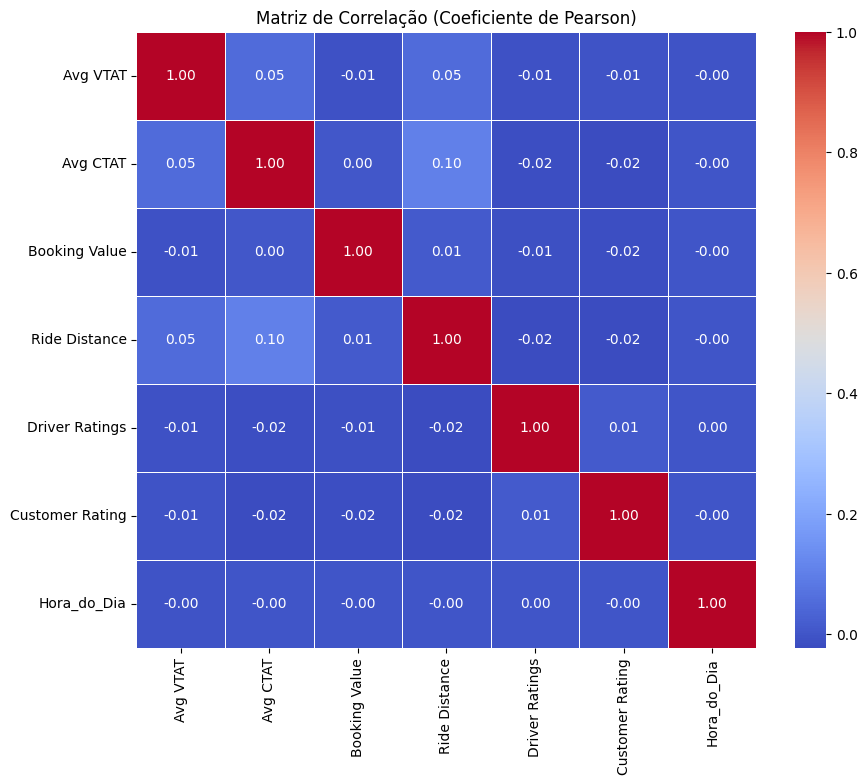

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# As 7 features numéricas originais (antes do escalonamento):
NUMERIC_FEATURES = [
    'Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 
    'Driver Ratings', 'Customer Rating', 'Hora_do_Dia' # Hora_do_Dia foi criada por engenharia de features
]

# 1. Preparação dos Dados (Limpeza Mínima)
# Usaremos o DataFrame 'df' original. Se houver NaNs nas colunas numéricas, 
# precisamos imputar ou remover para calcular a correlação. Usaremos a imputação por Mediana.
df_corr = df[NUMERIC_FEATURES].copy()

for col in ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']:
    df_corr[col].fillna(df_corr[col].median(), inplace=True)

# A Hora_do_Dia deve ser gerada novamente se o df não a tiver (como fizemos na preparação)
if 'Hora_do_Dia' not in df_corr.columns:
    df_corr['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df_corr['Hora_do_Dia'] = df_corr['DateTime'].dt.hour
    df_corr.drop(columns=['DateTime'], inplace=True)

# 2. Cálculo e Visualização da Matriz de Correlação
correlation_matrix = df_corr[NUMERIC_FEATURES].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True, # Mostrar os valores da correlação
            fmt=".2f",  # Formatar os valores com 2 casas decimais
            cmap='coolwarm', # Mapa de cores adequado para correlação (positivo/negativo)
            linewidths=.5, # Adicionar linhas entre as células
            cbar=True)
plt.title('Matriz de Correlação (Coeficiente de Pearson)')
plt.show()

# COMENTÁRIO CHAVE:
# - Procure valores próximos a 1.0 ou -1.0. 
# - Por exemplo, se 'Booking Value' e 'Ride Distance' tiverem alta correlação positiva (+0.80), 
#   significa que corridas mais longas geralmente têm maior valor.
# - Correlações altas podem indicar multicolinearidade, o que deve ser considerado na modelagem.


--- 📦 Visualização de Distribuição e Outliers (Box Plots) ---


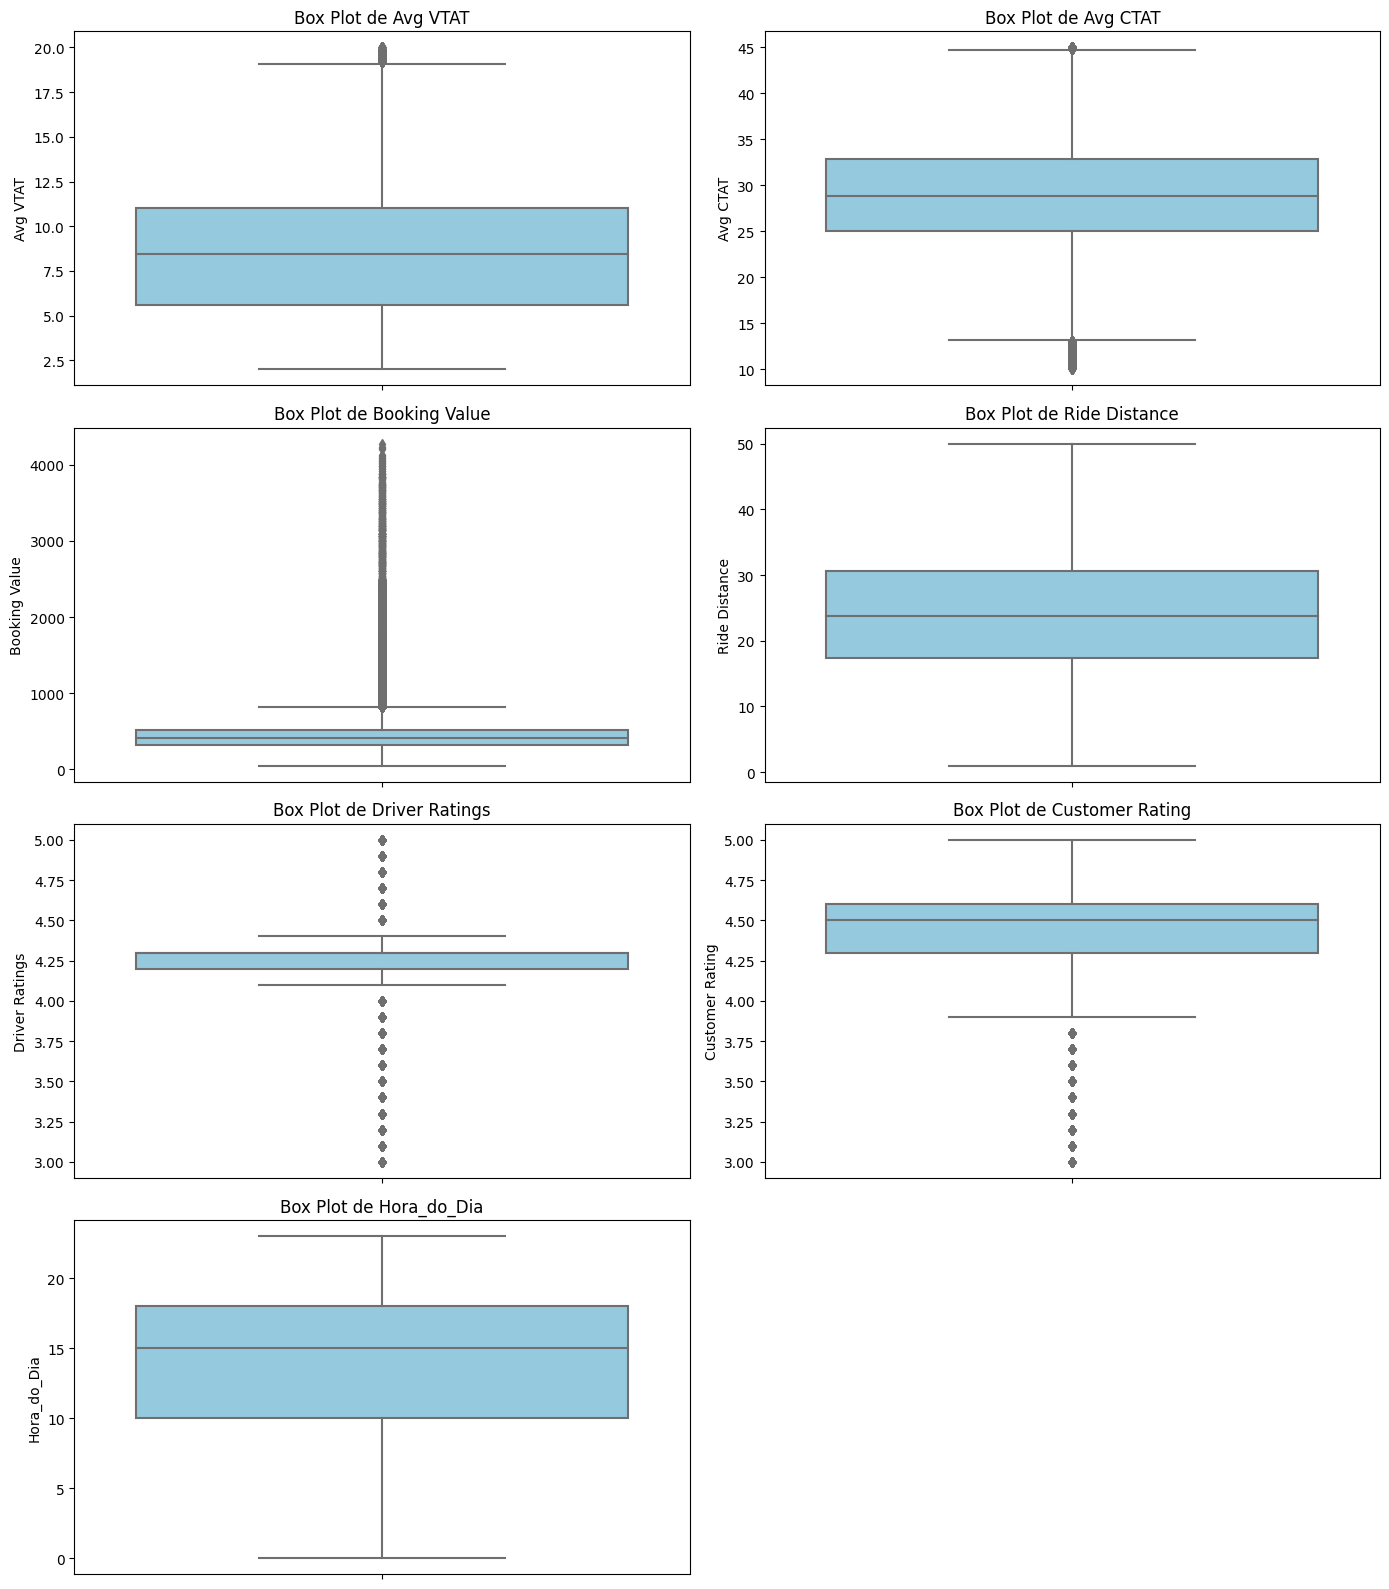

In [47]:
# 3. Box Plots para Distribuição e Outliers
print("\n--- 📦 Visualização de Distribuição e Outliers (Box Plots) ---")

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten() # Transforma a matriz de eixos em um array 1D

# Remove o último subplot vazio
fig.delaxes(axes[7])

for i, col in enumerate(NUMERIC_FEATURES):
    sns.boxplot(y=df_corr[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Box Plot de {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

# COMENTÁRIO CHAVE:
# - A linha dentro da caixa é a Mediana (50% dos dados).
# - A caixa representa 50% dos dados centrais (IQR).
# - Os pontos fora das hastes (whiskers) são os **Outliers**. 
# - Features como 'Ride Distance' e 'Booking Value' tipicamente terão muitos outliers (corridas muito longas ou caras).

--- 👁️ Visualização para Classificação (Modelos Supervisionados) ---


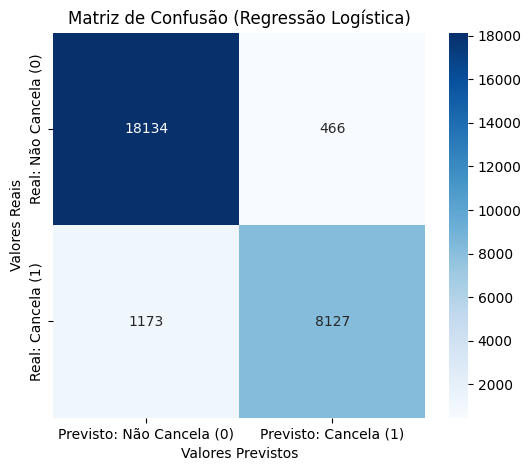

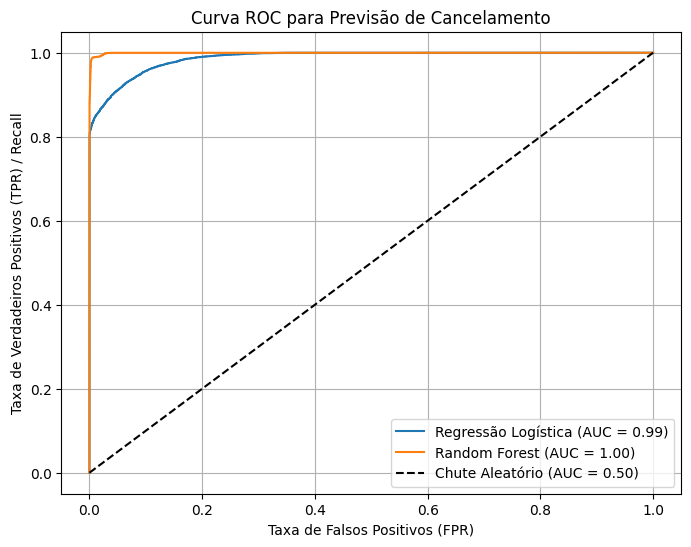

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

print("--- 👁️ Visualização para Classificação (Modelos Supervisionados) ---")

# 1. MATRIZ DE CONFUSÃO (Para Regressão Logística)
# O que mostra: Como o modelo acertou ou errou cada classe (Falsos Positivos, Falsos Negativos).
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Previsto: Não Cancela (0)', 'Previsto: Cancela (1)'],
            yticklabels=['Real: Não Cancela (0)', 'Real: Cancela (1)'])
plt.title('Matriz de Confusão (Regressão Logística)')
plt.ylabel('Valores Reais')
plt.xlabel('Valores Previstos')
plt.show()

# COMENTÁRIO: Mostre como interpretar:
# - Canto Superior Esquerdo: Verdadeiros Negativos (Acertos 'Não Cancela')
# - Canto Inferior Direito: Verdadeiros Positivos (Acertos 'Cancela')
# - Canto Superior Direito: Falsos Positivos (Errou 'Não Cancela')
# - Canto Inferior Esquerdo: Falsos Negativos (Errou 'Cancela' - o mais caro para o negócio!)

# 2. CURVA ROC (Receiver Operating Characteristic)
# O que mostra: A capacidade de ranqueamento do modelo em diferentes limiares.
# Comparando Regressão Logística e Random Forest.

# Calcula a curva ROC para cada modelo
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

# Calcula o AUC para exibir na legenda
auc_lr_val = roc_auc_score(y_test, y_proba_lr)
auc_rf_val = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr_val:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf_val:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chute Aleatório (AUC = 0.50)') # Linha de base
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) / Recall')
plt.title('Curva ROC para Previsão de Cancelamento')
plt.legend()
plt.grid(True)
plt.show()

# COMENTÁRIO: Um modelo bom tem a curva o mais perto possível do canto superior esquerdo.
# O Random Forest deve ter uma curva que "abraça" mais o canto, indicando melhor performance.



--- 🔭 Visualização para Agrupamento (Modelos Não Supervisionados) ---


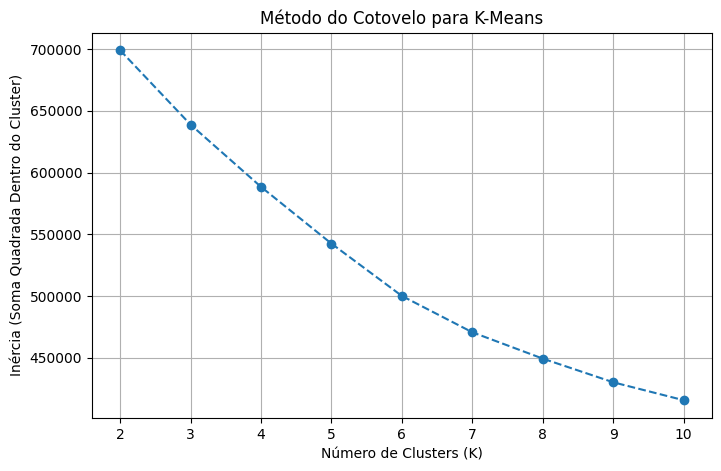

In [49]:
from sklearn.decomposition import PCA # Usaremos PCA para reduzir a dimensão para visualização
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans # Para recalcular inércia e mostrar o cotovelo
import numpy as np

print("\n\n--- 🔭 Visualização para Agrupamento (Modelos Não Supervisionados) ---")

# 1. MÉTODO DO COTOVELO (Para K-Means)
# O que mostra: Como escolher o número ideal de clusters (K).
# (Re-executando para a visualização, assumindo X_numeric já existe)
inertia_scores = []
K_range = range(2, 11) # Testar de 2 a 10 clusters
for k in K_range:
    kmeans_model_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_model_temp.fit(X_numeric)
    inertia_scores.append(kmeans_model_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_scores, marker='o', linestyle='--')
plt.title('Método do Cotovelo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Soma Quadrada Dentro do Cluster)')
plt.grid(True)
plt.show()

# COMENTÁRIO: Procure o ponto onde a curva forma um "cotovelo" e o declínio desacelera. 
# Esse é o K_ideal onde adicionar mais clusters não traz tanto benefício.

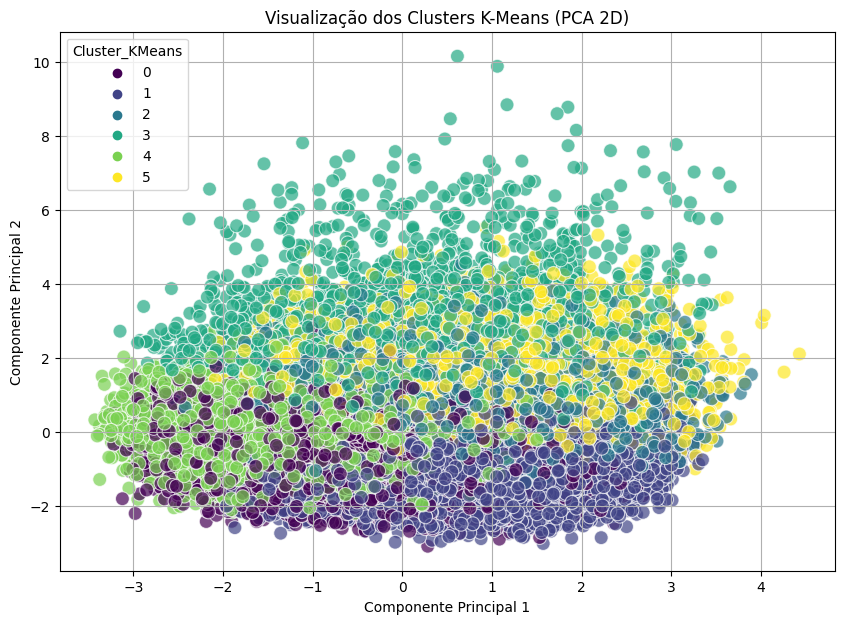

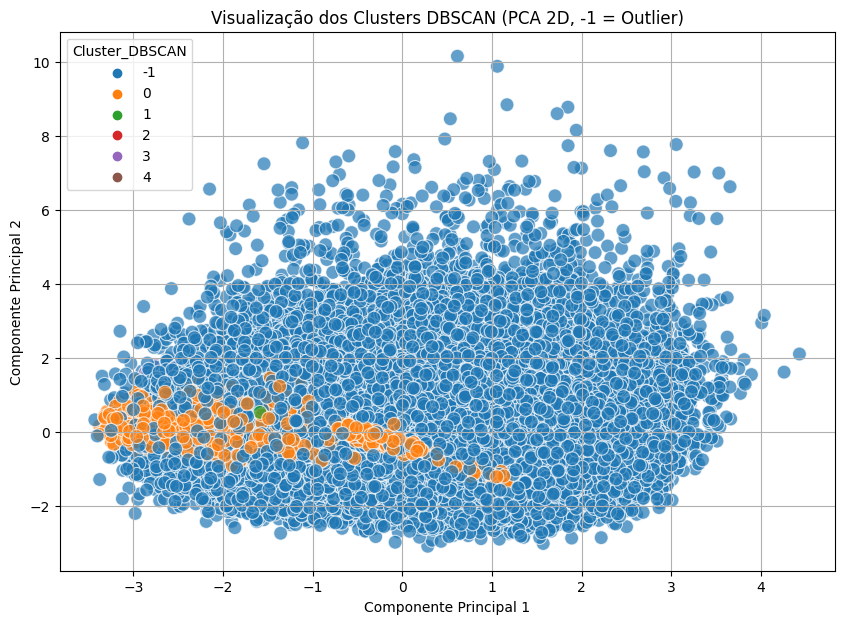

In [50]:
# 2. VISUALIZAÇÃO DOS CLUSTERS (Usando PCA para Redução de Dimensionalidade)
# O que mostra: Como os pontos foram agrupados no espaço de features.
# Problema: Nossos dados têm 7 dimensões numéricas. Não podemos plotar em 7D.
# Solução: Usar PCA para reduzir para 2 ou 3 dimensões para visualização.

pca = PCA(n_components=2) # Reduzir para 2 componentes principais
X_pca = pca.fit_transform(X_numeric)

# Criar um DataFrame para facilitar o plot
df_clusters_viz = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_clusters_viz['Cluster_KMeans'] = clusters_kmeans # Rótulos do K-Means
df_clusters_viz['Cluster_DBSCAN'] = clusters_dbscan # Rótulos do DBSCAN

# Plot para K-Means
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster_KMeans', 
                palette='viridis', data=df_clusters_viz, legend='full', s=100, alpha=0.7)
plt.title('Visualização dos Clusters K-Means (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# Plot para DBSCAN (mostrando outliers)
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster_DBSCAN', 
                palette='tab10', data=df_clusters_viz, legend='full', s=100, alpha=0.7)
plt.title('Visualização dos Clusters DBSCAN (PCA 2D, -1 = Outlier)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# COMENTÁRIO:
# - K-Means: Mostra clusters mais "redondos" e com tamanhos similares.
# - DBSCAN: Pode mostrar clusters de formas irregulares e claramente identificar os outliers (pontos com cor '-1').
# Explique que o PCA comprime a informação, mas permite uma ideia visual da separação.